# Encounter Utilization Analysis

## Healthcare Analytics Project

### Objective
Analyze healthcare encounter patterns to understand how healthcare services are utilized across encounter types, patients, time periods, and clinical conditions.

## Analysis Scope

This analysis focuses on encounter-level healthcare utilization.

### Key Areas
- Encounter volume and encounter types
- Patient-level encounter utilization
- Encounter duration and length of stay
- Healthcare utilization patterns over time
- Utilization across demographic groups
- Utilization associated with clinical conditions
- High-utilization and repeat-encounter patterns
- Healthcare utilization KPIs

### Analytical Goal
Identify meaningful patterns in healthcare service utilization that can support healthcare operations, resource planning, and population-level analysis.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
encounters=pd.read_csv("C:\projects\Healthcare-Analytics-Dashboard\python\data\encounters.csv")

In [19]:
encounters.head()

,Id,START,STOP,PATIENT,ORGANIZATION,PROVIDER,PAYER,ENCOUNTERCLASS,CODE,DESCRIPTION,BASE_ENCOUNTER_COST,TOTAL_CLAIM_COST,PAYER_COVERAGE,REASONCODE,REASONDESCRIPTION
0,d5ee30a9-362f-429e-a87a-ee38d999b0a5,2019-02-16T01:02:32Z,2019-02-16T01:17:32Z,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,5103c940-0c08-392f-95cd-446e0cea042a,e2c226c2-3e1e-3d0b-b997-ce9544c10528,7c4411ce-02f1-39b5-b9ec-dfbea9ad3c1a,outpatient,185345009,Encounter for symptom,129.16,129.16,69.16,65363002.0,Otitis media
1,6a74fdef-2287-44bf-b9e7-18012376faca,2019-08-02T01:02:32Z,2019-08-02T01:32:32Z,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,0b9f3f7c-8ab6-30a5-b3ae-4dc0e0c00cb3,87c33fc5-3fd1-3c52-815a-b89a1623bb3a,7c4411ce-02f1-39b5-b9ec-dfbea9ad3c1a,wellness,410620009,Well child visit (procedure),129.16,129.16,129.16,NaN,NaN
2,8bca6d8a-ab80-4cbf-8abb-46654235f227,2019-10-31T01:02:32Z,2019-10-31T01:17:32Z,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,5103c940-0c08-392f-95cd-446e0cea042a,e2c226c2-3e1e-3d0b-b997-ce9544c10528,7c4411ce-02f1-39b5-b9ec-dfbea9ad3c1a,outpatient,185345009,Encounter for symptom,129.16,129.16,69.16,65363002.0,Otitis media
3,821e57ac-9304-46a9-9f9b-83daf60e9e43,2020-01-31T01:02:32Z,2020-01-31T01:17:32Z,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,0b9f3f7c-8ab6-30a5-b3ae-4dc0e0c00cb3,87c33fc5-3fd1-3c52-815a-b89a1623bb3a,7c4411ce-02f1-39b5-b9ec-dfbea9ad3c1a,wellness,410620009,Well child visit (procedure),129.16,129.16,129.16,NaN,NaN
4,681c380b-3c84-4c55-80a6-db3d9ea12fee,2020-03-02T01:02:32Z,2020-03-02T01:58:32Z,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,fd328395-ab1d-35c6-a2d0-d05a9a79cf11,9c875a09-93e0-39aa-9260-ad264bbdd3fe,7c4411ce-02f1-39b5-b9ec-dfbea9ad3c1a,ambulatory,185345009,Encounter for symptom (procedure),129.16,129.16,69.16,NaN,NaN


In [20]:
encounters.shape

(321528, 15)

In [21]:
encounters.info(
    
    
    
)

<class 'pandas.DataFrame'>
RangeIndex: 321528 entries, 0 to 321527
Data columns (total 15 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Id                   321528 non-null  str    
 1   START                321528 non-null  str    
 2   STOP                 321528 non-null  str    
 3   PATIENT              321528 non-null  str    
 4   ORGANIZATION         321528 non-null  str    
 5   PROVIDER             321528 non-null  str    
 6   PAYER                321528 non-null  str    
 7   ENCOUNTERCLASS       321528 non-null  str    
 8   CODE                 321528 non-null  int64  
 9   DESCRIPTION          321528 non-null  str    
 10  BASE_ENCOUNTER_COST  321528 non-null  float64
 11  TOTAL_CLAIM_COST     321528 non-null  float64
 12  PAYER_COVERAGE       321528 non-null  float64
 13  REASONCODE           71252 non-null   float64
 14  REASONDESCRIPTION    71252 non-null   str    
dtypes: float64(4), int64(1), str

In [22]:
encounters.columns.tolist()

['Id',
 'START',
 'STOP',
 'PATIENT',
 'ORGANIZATION',
 'PROVIDER',
 'PAYER',
 'ENCOUNTERCLASS',
 'CODE',
 'DESCRIPTION',
 'BASE_ENCOUNTER_COST',
 'TOTAL_CLAIM_COST',
 'PAYER_COVERAGE',
 'REASONCODE',
 'REASONDESCRIPTION']

In [23]:
encounters.isnull().sum()

Id                          0
START                       0
STOP                        0
PATIENT                     0
ORGANIZATION                0
PROVIDER                    0
PAYER                       0
ENCOUNTERCLASS              0
CODE                        0
DESCRIPTION                 0
BASE_ENCOUNTER_COST         0
TOTAL_CLAIM_COST            0
PAYER_COVERAGE              0
REASONCODE             250276
REASONDESCRIPTION      250276
dtype: int64

In [24]:
encounters.duplicated().sum()

np.int64(0)

In [25]:
encounters['Id'].duplicated().sum()

np.int64(0)

In [26]:
encounters['Id'].nunique()

321528

In [27]:
encounters['ENCOUNTERCLASS'].value_counts()

ENCOUNTERCLASS
wellness      156219
ambulatory     86069
outpatient     58367
inpatient       9584
emergency       7233
urgentcare      4056
Name: count, dtype: int64

In [28]:
encounters['START']=pd.to_datetime(encounters['START'])
encounters['STOP']=pd.to_datetime(encounters['STOP'])

In [29]:
encounters[["START", "STOP"]].dtypes

START    datetime64[us, UTC]
STOP     datetime64[us, UTC]
dtype: object

 Create Encounter Duration

In [30]:
encounters["DURATION_HOURS"]=(encounters['STOP']-encounters['START']).dt.total_seconds()/3600
encounters.head(3)

,Id,START,STOP,PATIENT,ORGANIZATION,PROVIDER,PAYER,ENCOUNTERCLASS,CODE,DESCRIPTION,BASE_ENCOUNTER_COST,TOTAL_CLAIM_COST,PAYER_COVERAGE,REASONCODE,REASONDESCRIPTION,DURATION_HOURS
0,d5ee30a9-362f-429e-a87a-ee38d999b0a5,2019-02-16 01:02:32+00:00,2019-02-16 01:17:32+00:00,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,5103c940-0c08-392f-95cd-446e0cea042a,e2c226c2-3e1e-3d0b-b997-ce9544c10528,7c4411ce-02f1-39b5-b9ec-dfbea9ad3c1a,outpatient,185345009,Encounter for symptom,129.16,129.16,69.16,65363002.0,Otitis media,0.25
1,6a74fdef-2287-44bf-b9e7-18012376faca,2019-08-02 01:02:32+00:00,2019-08-02 01:32:32+00:00,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,0b9f3f7c-8ab6-30a5-b3ae-4dc0e0c00cb3,87c33fc5-3fd1-3c52-815a-b89a1623bb3a,7c4411ce-02f1-39b5-b9ec-dfbea9ad3c1a,wellness,410620009,Well child visit (procedure),129.16,129.16,129.16,NaN,NaN,0.50
2,8bca6d8a-ab80-4cbf-8abb-46654235f227,2019-10-31 01:02:32+00:00,2019-10-31 01:17:32+00:00,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,5103c940-0c08-392f-95cd-446e0cea042a,e2c226c2-3e1e-3d0b-b997-ce9544c10528,7c4411ce-02f1-39b5-b9ec-dfbea9ad3c1a,outpatient,185345009,Encounter for symptom,129.16,129.16,69.16,65363002.0,Otitis media,0.25


In [32]:
encounters["DURATION_HOURS"].describe()

count    321528.000000
mean        233.440959
std        8748.100255
min           0.250000
25%           0.250000
50%           0.250000
75%           0.500000
max      741048.000000
Name: DURATION_HOURS, dtype: float64

In [33]:
(encounters["DURATION_HOURS"] < 0).sum()

np.int64(0)

In [34]:
(encounters["DURATION_HOURS"] == 0).sum()

np.int64(0)

In [35]:
encounters.nlargest(10, "DURATION_HOURS")[
    ["Id", "PATIENT", "START", "STOP", "ENCOUNTERCLASS", "DESCRIPTION", "DURATION_HOURS"]
]

,Id,PATIENT,START,STOP,ENCOUNTERCLASS,DESCRIPTION,DURATION_HOURS
110180,f298b802-bb21-4ee5-9658-c3d3f028ba07,d52fad1a-294d-4b04-88be-1ee34dca1e36,1935-05-30 19:42:16+00:00,2019-12-12 19:42:16+00:00,outpatient,Encounter for check up (procedure),741048.00
136962,2acb73f4-60f6-4624-a1f1-d2f711e9a969,e5a3f36b-a64c-4532-97a6-ce222b88517c,1928-12-30 23:52:45+00:00,2005-10-02 23:52:45+00:00,outpatient,Encounter for check up (procedure),672840.00
311808,1f46407b-6ab5-47fc-b86b-5fe24a557e01,cd6b6dfe-a402-40d2-a394-2779e55dc055,1927-11-05 02:43:03+00:00,2000-07-15 02:43:03+00:00,outpatient,Encounter for check up (procedure),637224.00
71344,4aef7210-333b-47fd-af19-c0a67bc294b4,f742ce19-f878-44df-b1eb-fbd9eb619269,1922-01-30 20:32:40+00:00,1989-08-14 20:32:40+00:00,outpatient,Encounter for check up (procedure),592032.00
301539,e1a3ec51-2686-4feb-84aa-6ea866b6901f,00b5b3b8-1c65-443e-b3c0-c0a11a733278,1948-09-27 14:13:26+00:00,2015-04-20 14:28:26+00:00,outpatient,Encounter for check up (procedure),583464.25
112269,d853b5ee-39f3-48f8-8666-4397c1835fe3,8e29f7d8-a3e7-4bcc-88cd-f3ec535c2de3,1927-05-11 10:29:25+00:00,1993-04-07 10:29:25+00:00,outpatient,Encounter for check up (procedure),577752.00
90781,d7643bb0-66c0-43c8-98c4-98c91539638e,4bd785fe-657a-4b1c-8fc9-3b64015606d6,1955-08-04 16:06:26+00:00,2019-07-18 16:21:26+00:00,outpatient,Encounter for check up (procedure),560616.25
72020,7d141c4a-8b56-49cb-b27d-b7bd10a5dbd2,b98e0fcc-0e5d-4fb4-aec0-5cd80f84160f,1940-03-13 07:09:01+00:00,2003-11-19 07:09:01+00:00,outpatient,Encounter for check up (procedure),558264.00
16093,ae289c60-f4e7-40e4-89cc-7fc0fb805a71,ef6a51c3-5dbc-4f95-a86a-351a0edb7aa2,1956-05-13 11:34:13+00:00,2019-06-30 11:34:13+00:00,outpatient,Encounter for check up (procedure),553392.00
282164,2f91fd36-62f9-412e-b8a6-3e357db8e21b,88499c86-11b1-4934-9c82-a140524a88b8,1957-06-26 14:44:28+00:00,2019-05-08 14:44:28+00:00,outpatient,Encounter for check up (procedure),542304.00


In [36]:
encounters.groupby('ENCOUNTERCLASS')['DURATION_HOURS'].agg(["count", "median", "mean", "max"]).sort_values('median',ascending=False)

,count,median,mean,max
ENCOUNTERCLASS,,,,
inpatient,9584,25.000000,442.041375,516196.083333
emergency,7233,1.483333,674.508461,442032.000000
ambulatory,86069,0.250000,18.173949,341305.000000
outpatient,58367,0.250000,1101.934364,741048.000000
urgentcare,4056,0.250000,0.250000,0.250000
wellness,156219,0.250000,0.388747,4.250000


In [37]:
encounters.groupby("ENCOUNTERCLASS")["DURATION_HOURS"].quantile(0.99)  #This gives us the 99th percentile duration for each encounter type.

ENCOUNTERCLASS
ambulatory    336.000000
emergency       3.894667
inpatient     507.548833
outpatient      1.233333
urgentcare      0.250000
wellness        1.000000
Name: DURATION_HOURS, dtype: float64

# Encounter Volume by Type

How are healthcare encounters distributed across encounter types?

In [38]:
encounter_type_summary = (
    encounters["ENCOUNTERCLASS"]
    .value_counts()
    .reset_index()
)
encounter_type_summary.columns=["Encounter Type", "Encounter Count"]
encounter_type_summary

,Encounter Type,Encounter Count
0,wellness,156219
1,ambulatory,86069
2,outpatient,58367
3,inpatient,9584
4,emergency,7233
5,urgentcare,4056


In [39]:
encounter_type_summary["Percentage"] = (
    encounter_type_summary["Encounter Count"]
    / encounter_type_summary["Encounter Count"].sum()
    * 100
)

encounter_type_summary

,Encounter Type,Encounter Count,Percentage
0,wellness,156219,48.586437
1,ambulatory,86069,26.768742
2,outpatient,58367,18.153007
3,inpatient,9584,2.980767
4,emergency,7233,2.249571
5,urgentcare,4056,1.261476


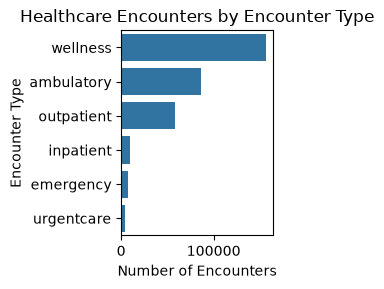

In [40]:
plt.figure(figsize=(3, 3))

sns.barplot(
    data=encounter_type_summary,
    x="Encounter Count",
    y="Encounter Type"
)

plt.title("Healthcare Encounters by Encounter Type")
plt.xlabel("Number of Encounters")
plt.ylabel("Encounter Type")
plt.tight_layout()
plt.show()

Wellness encounters represent nearly half of all encounters in this dataset, followed by ambulatory and outpatient encounters. Inpatient, emergency, and urgent-care encounters constitute substantially smaller proportions.

# Encounter Volume Over Time.

How does healthcare encounter volume change over time?

Count encounters by year

In [41]:
encounters.head(2)

,Id,START,STOP,PATIENT,ORGANIZATION,PROVIDER,PAYER,ENCOUNTERCLASS,CODE,DESCRIPTION,BASE_ENCOUNTER_COST,TOTAL_CLAIM_COST,PAYER_COVERAGE,REASONCODE,REASONDESCRIPTION,DURATION_HOURS
0,d5ee30a9-362f-429e-a87a-ee38d999b0a5,2019-02-16 01:02:32+00:00,2019-02-16 01:17:32+00:00,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,5103c940-0c08-392f-95cd-446e0cea042a,e2c226c2-3e1e-3d0b-b997-ce9544c10528,7c4411ce-02f1-39b5-b9ec-dfbea9ad3c1a,outpatient,185345009,Encounter for symptom,129.16,129.16,69.16,65363002.0,Otitis media,0.25
1,6a74fdef-2287-44bf-b9e7-18012376faca,2019-08-02 01:02:32+00:00,2019-08-02 01:32:32+00:00,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,0b9f3f7c-8ab6-30a5-b3ae-4dc0e0c00cb3,87c33fc5-3fd1-3c52-815a-b89a1623bb3a,7c4411ce-02f1-39b5-b9ec-dfbea9ad3c1a,wellness,410620009,Well child visit (procedure),129.16,129.16,129.16,NaN,NaN,0.50


In [42]:
encounters["START"] = pd.to_datetime(encounters["START"])

In [43]:
encounters["START"].dtype

datetime64[us, UTC]

In [44]:
encounters["YEAR"] = encounters["START"].dt.year

In [45]:
encounters[["START", "YEAR"]]

,START,YEAR
0,2019-02-16 01:02:32+00:00,2019
1,2019-08-02 01:02:32+00:00,2019
2,2019-10-31 01:02:32+00:00,2019
3,2020-01-31 01:02:32+00:00,2020
4,2020-03-02 01:02:32+00:00,2020
...,...,...
321523,2020-05-19 06:03:58+00:00,2020
321524,2020-05-26 06:03:58+00:00,2020
321525,2020-05-22 06:03:58+00:00,2020
321526,2020-05-22 06:03:58+00:00,2020


In [46]:
yearly_encounters=encounters.groupby('YEAR').size().reset_index(name='encounter count')
yearly_encounters

,YEAR,encounter count
0,1910,4
1,1911,9
2,1912,18
3,1913,12
4,1914,13
...,...,...
106,2016,7753
107,2017,7765
108,2018,8722
109,2019,25428


In [47]:
encounters["START"].min(), encounters["START"].max()

(Timestamp('1910-06-26 16:46:17+0000', tz='UTC'),
 Timestamp('2020-05-27 19:46:05+0000', tz='UTC'))

In [48]:
encounters["STOP"].min(), encounters["STOP"].max()

(Timestamp('1910-06-26 20:18:17+0000', tz='UTC'),
 Timestamp('2020-05-27 20:01:05+0000', tz='UTC'))

In [49]:
yearly_encounters["Percentage"] = (
    yearly_encounters["encounter count"]
    / yearly_encounters["encounter count"].sum()
    * 100
)

yearly_encounters

,YEAR,encounter count,Percentage
0,1910,4,0.001244
1,1911,9,0.002799
2,1912,18,0.005598
3,1913,12,0.003732
4,1914,13,0.004043
...,...,...,...
106,2016,7753,2.411299
107,2017,7765,2.415031
108,2018,8722,2.712672
109,2019,25428,7.908487


In [50]:
yearly_encounters[yearly_encounters["YEAR"] >= 2015]

,YEAR,encounter count,Percentage
105,2015,7429,2.310530
106,2016,7753,2.411299
107,2017,7765,2.415031
108,2018,8722,2.712672
109,2019,25428,7.908487
110,2020,25900,8.055286


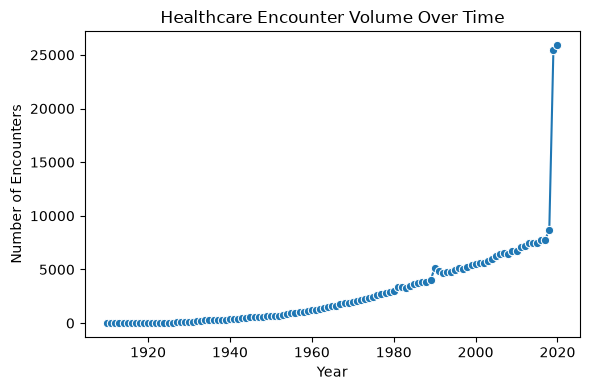

In [51]:
plt.figure(figsize=(6, 4))

sns.lineplot(
    data=yearly_encounters,
    x="YEAR",
    y="encounter count",
    marker="o"
)

plt.title("Healthcare Encounter Volume Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Encounters")
plt.tight_layout()
plt.show()

In [52]:
#Encounter volume increased substantially in 2019 and remained elevated in 2020.

Year-over-Year Change

How much did encounter volume change from one year to the next?

In [53]:
yearly_encounters['YoY Change (%)']=yearly_encounters['encounter count'].pct_change()*100

In [54]:
yearly_encounters.head(10)

#Logic

#.pct_change() compares each year's value with the previous year's value.

,YEAR,encounter count,Percentage,YoY Change (%)
0,1910,4,0.001244,NaN
1,1911,9,0.002799,125.000000
2,1912,18,0.005598,100.000000
3,1913,12,0.003732,-33.333333
4,1914,13,0.004043,8.333333
5,1915,33,0.010263,153.846154
6,1916,32,0.009952,-3.030303
7,1917,28,0.008708,-12.500000
8,1918,27,0.008397,-3.571429
9,1919,51,0.015862,88.888889


In [55]:
yearly_encounters[yearly_encounters['YEAR']>= 2015]

,YEAR,encounter count,Percentage,YoY Change (%)
105,2015,7429,2.310530,-0.375486
106,2016,7753,2.411299,4.361287
107,2017,7765,2.415031,0.154779
108,2018,8722,2.712672,12.324533
109,2019,25428,7.908487,191.538638
110,2020,25900,8.055286,1.856221


2019 is the major utilization change point.


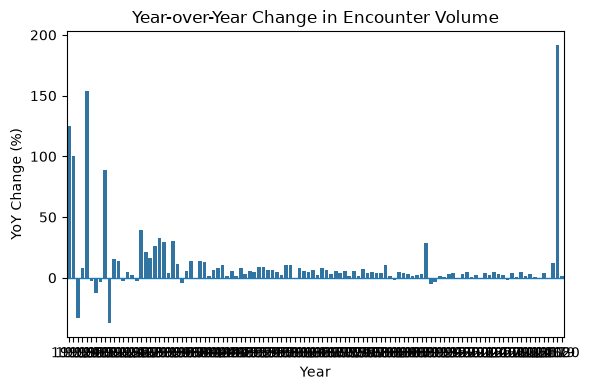

In [61]:
plt.figure(figsize=(6, 4))

sns.barplot(
    data=yearly_encounters.iloc[1:],
    x="YEAR",
    y="YoY Change (%)"
)

plt.axhline(0, linewidth=1)

plt.title("Year-over-Year Change in Encounter Volume")
plt.xlabel("Year")
plt.ylabel("YoY Change (%)")
plt.tight_layout()
plt.show()




# Patient Encounter Utilization

How many healthcare encounters does each patient have, and how concentrated is healthcare utilization among patients?

In [62]:
patient_encounters=encounters.groupby('PATIENT').size().reset_index(name='encounter_count')

In [63]:
patient_encounters.head(10)

,PATIENT,encounter_count
0,0000b247-1def-417a-a783-41c8682be022,3
1,00049ee8-5953-4edd-a277-b9c1b1a7f16b,8
2,000769a6-23a7-426e-a264-cb0e509b2da2,4
3,00079a57-24a8-430f-b4f8-a1cf34f90060,20
4,0008a63c-c95c-46c2-9ef3-831d68892019,5
5,00093cdd-a9f0-4ad8-87e9-53534501f008,85
6,000aa2a0-e307-456f-9f71-c11ab3fc024c,8
7,000e7adf-cbaa-4fad-ab2f-658c32f7d4d3,47
8,0013bde7-14fe-482f-9547-a29077b87904,7
9,001683f0-8546-4ac2-9153-dd1a9ffe29cd,3


What does the distribution of encounters per patient look like?

In [64]:
#This tells us whether most patients have relatively few encounters while a smaller group has very high utilization.

In [65]:
patient_encounters['encounter_count'].describe()

#We want to know:

#How are those 321,528 encounters distributed across patients?

count    12330.000000
mean        26.076886
std         44.951315
min          1.000000
25%          5.000000
50%         10.000000
75%         33.000000
max        825.000000
Name: encounter_count, dtype: float64

Most patients have relatively few encounters, while a smaller group of patients has very high encounter utilization and pulls the average upward.

# How is encounter utilization distributed across patients?

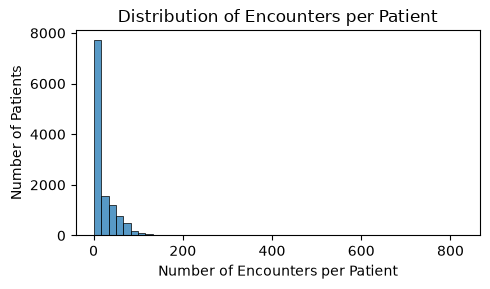

In [66]:
plt.figure(figsize=(5, 3))

sns.histplot(
    data=patient_encounters,   #histplot() divides patients into encounter-count ranges and counts how many patients fall into each range.
    x="encounter_count",
    bins=50
)

plt.title("Distribution of Encounters per Patient")
plt.xlabel("Number of Encounters per Patient")
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.show()

A very large number of patients have relatively few encounters.
The number of patients decreases rapidly as encounter count increases.
A small number of patients have much higher utilization.
The long tail extends all the way to 825 encounters.

---Who are the high-utilization patients?

In [67]:
high_utilization_threshold = patient_encounters["encounter_count"].quantile(0.95)   # .quantile(0.95) "What encounter count separates the highest 5% of patients from the other 95%?"

high_utilization_threshold

np.float64(83.0)

≤83 encounters → approximately 95% of patients

83 encounters → approximately highest 5%

That means the highest-utilization group is approximately the top 5% of patients with more than 83 encounters.

In [68]:
high_utilization_patients = patient_encounters[patient_encounters['encounter_count']>high_utilization_threshold]

high_utilization_patients.head(10)

,PATIENT,encounter_count
5,00093cdd-a9f0-4ad8-87e9-53534501f008,85
35,00848f6c-3abd-4963-b472-563dadb8ac7f,104
51,00c4a300-1dd2-40cb-a7c5-98d8dbb5e5d0,485
68,00fb0c2d-042a-45c8-afba-a643803e9ce7,86
78,0138b15c-2616-4be2-9755-14255878cd99,89
85,015b7c69-8db0-4785-be23-56069a738b14,106
89,016861de-80d1-4e98-9266-62284b1a5952,173
98,0193adec-2f4b-41c5-961c-0e41e511abaa,109
106,01a10467-d21d-4407-b22e-9c1d620871b6,88
158,02d33b53-1387-4980-8217-2bf6cf05e520,91


In [69]:
total_patients = len(patient_encounters)

high_utilization_count = len(high_utilization_patients)

high_utilization_patient_pct = (
    high_utilization_count / total_patients * 100
)

total_encounters = patient_encounters["encounter_count"].sum()

high_utilization_encounters = (
    high_utilization_patients["encounter_count"].sum()
)

high_utilization_encounter_pct = (
    high_utilization_encounters / total_encounters * 100
)

print("Total patients:", total_patients)
print("High-utilization patients:", high_utilization_count)
print("High-utilization patients (%):", round(high_utilization_patient_pct, 2))
print("Total encounters:", total_encounters)
print("Encounters from high-utilization patients:", high_utilization_encounters)
print("Share of encounters from high-utilization patients (%):",
      round(high_utilization_encounter_pct, 2))

Total patients: 12330
High-utilization patients: 614
High-utilization patients (%): 4.98
Total encounters: 321528
Encounters from high-utilization patients: 103197
Share of encounters from high-utilization patients (%): 32.1


# Only 4.98% of patients generated 32.1% of all healthcare encounters.

Do high-utilization patients have a different pattern of encounter types compared with the overall patient population?

Identify encounter types among high-utilization patients

In [76]:
high_utilization_ids = high_utilization_patients["PATIENT"]

high_utilization_encounters = encounters[
    encounters["PATIENT"].isin(high_utilization_ids)
]

high_utilization_type_summary = (
    high_utilization_encounters["ENCOUNTERCLASS"]
    .value_counts()
    .reset_index()
)

high_utilization_type_summary.columns = [
    "Encounter Type",
    "Encounter Count"
]

high_utilization_type_summary # only the hiheruntilization patients data and their distribution into encountertypes.

,Encounter Type,Encounter Count
0,outpatient,42268
1,wellness,33088
2,ambulatory,21909
3,urgentcare,3233
4,inpatient,1400
5,emergency,1299


In [77]:
high_utilization_type_summary['Encounter Count'].sum()

np.int64(103197)

Is this distribution actually different from the overall encounter distribution?

In [78]:
high_utilization_type_summary["Percentage"] = (
    high_utilization_type_summary["Encounter Count"]
    / high_utilization_type_summary["Encounter Count"].sum()
    * 100
)

high_utilization_type_summary

,Encounter Type,Encounter Count,Percentage
0,outpatient,42268,40.958555
1,wellness,33088,32.062948
2,ambulatory,21909,21.230268
3,urgentcare,3233,3.132843
4,inpatient,1400,1.356629
5,emergency,1299,1.258758


Do high-utilization patients have longer encounters?
Do high-utilization patients have longer healthcare encounters than other patients?

In [80]:
high_utilization_ids = set(high_utilization_patients["PATIENT"])

encounters["UTILIZATION_GROUP"] = encounters["PATIENT"].apply(
    lambda x: "High Utilization" if x in high_utilization_ids else "Other Patients"
)

encounters.groupby("UTILIZATION_GROUP")["DURATION_HOURS"].agg(
    ["count", "median", "mean", "max"]
)

,count,median,mean,max
UTILIZATION_GROUP,,,,
High Utilization,103197,0.25,197.158973,741048.00
Other Patients,218331,0.25,250.590113,583464.25


In [81]:
encounters["UTILIZATION_GROUP"] = encounters["PATIENT"].apply(
    lambda x: "High Utilization" if x in high_utilization_ids else "Other Patients"
)

In [85]:
encounters.head(2)

,Id,START,STOP,PATIENT,ORGANIZATION,PROVIDER,PAYER,ENCOUNTERCLASS,CODE,DESCRIPTION,BASE_ENCOUNTER_COST,TOTAL_CLAIM_COST,PAYER_COVERAGE,REASONCODE,REASONDESCRIPTION,DURATION_HOURS,YEAR,UTILIZATION_GROUP
0,d5ee30a9-362f-429e-a87a-ee38d999b0a5,2019-02-16 01:02:32+00:00,2019-02-16 01:17:32+00:00,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,5103c940-0c08-392f-95cd-446e0cea042a,e2c226c2-3e1e-3d0b-b997-ce9544c10528,7c4411ce-02f1-39b5-b9ec-dfbea9ad3c1a,outpatient,185345009,Encounter for symptom,129.16,129.16,69.16,65363002.0,Otitis media,0.25,2019,Other Patients
1,6a74fdef-2287-44bf-b9e7-18012376faca,2019-08-02 01:02:32+00:00,2019-08-02 01:32:32+00:00,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,0b9f3f7c-8ab6-30a5-b3ae-4dc0e0c00cb3,87c33fc5-3fd1-3c52-815a-b89a1623bb3a,7c4411ce-02f1-39b5-b9ec-dfbea9ad3c1a,wellness,410620009,Well child visit (procedure),129.16,129.16,129.16,NaN,NaN,0.50,2019,Other Patients


In [84]:
encounters.groupby("UTILIZATION_GROUP")["DURATION_HOURS"].agg(
    ["count", "median", "mean", "max"]
)

,count,median,mean,max
UTILIZATION_GROUP,,,,
High Utilization,103197,0.25,197.158973,741048.00
Other Patients,218331,0.25,250.590113,583464.25


We use median as the main comparison because your duration data are extremely right-skewed, as we already saw from the huge maximum values.

The important finding

No — high-utilization patients do not have longer typical encounters.

The median duration is 0.25 hours for both groups, which is:

0.25 × 60 = 15 minutes.

So the typical encounter is approximately 15 minutes in both groups.

High-utilization patients have the same typical encounter duration as other patients (median = 0.25 hours), suggesting that their high utilization is driven primarily by encounter frequency rather than longer individual encounters.

# Do high-utilization patients account for a disproportionate share of healthcare encounters?

How concentrated is healthcare utilization?
Business question

Do a small proportion of patients account for a disproportionately large share of all healthcare encounters?

Create the comparison table

In [87]:
total_patients = len(patient_encounters)

high_utilization_patient_count = len(high_utilization_patients)

total_encounter_count = len(encounters)

high_utilization_encounter_count = len(high_utilization_encounters)

utilization_concentration = pd.DataFrame({
    "Group": ["High Utilization Patients", "Other Patients"],
    
    "Patient Count": [
        high_utilization_patient_count,
        total_patients - high_utilization_patient_count
    ],
    
    "Encounter Count": [
        high_utilization_encounter_count,
        total_encounter_count - high_utilization_encounter_count
    ]
})

utilization_concentration["Patient Percentage"] = (
    utilization_concentration["Patient Count"]
    / total_patients * 100
)

utilization_concentration["Encounter Percentage"] = (
    utilization_concentration["Encounter Count"]
    / total_encounter_count * 100
)

utilization_concentration

,Group,Patient Count,Encounter Count,Patient Percentage,Encounter Percentage
0,High Utilization Patients,614,103197,4.979724,32.095805
1,Other Patients,11716,218331,95.020276,67.904195


Only 4.98% of patients generated 32.10% of all healthcare encounters.

In other words, the small high-utilization group generates encounters at a much higher rate than its population share.

calculate:

Encounter share ÷ Patient share

In [88]:
concentration_ratio = (
    utilization_concentration.loc[0, "Encounter Percentage"]
    / utilization_concentration.loc[0, "Patient Percentage"]
)

concentration_ratio

np.float64(6.445297655243445)

So the high-utilization group accounts for encounters at roughly 6.4× its share of the patient population.

Visualize utilization concentration  ---How does the share of patients compare with their share of healthcare encounters?

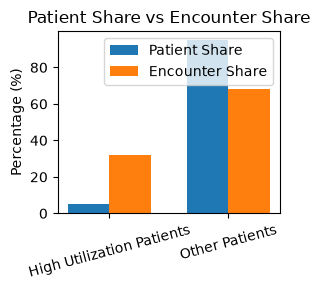

In [89]:
plt.figure(figsize=(3, 3))

x = np.arange(len(utilization_concentration))
width = 0.35

plt.bar(
    x - width/2,
    utilization_concentration["Patient Percentage"],
    width,
    label="Patient Share"
)

plt.bar(
    x + width/2,
    utilization_concentration["Encounter Percentage"],
    width,
    label="Encounter Share"
)

plt.xticks(
    x,
    utilization_concentration["Group"],
    rotation=15
)

plt.ylabel("Percentage (%)")
plt.title("Patient Share vs Encounter Share")
plt.legend()

plt.tight_layout()
plt.show()

Patient Encounter Intensity

Question:

How does encounter intensity vary across patients, and how concentrated is repeated healthcare utilization among patients with multiple encounters?

How many patients fall into each encounter-intensity tier?

In [90]:
patient_encounters["UTILIZATION_TIER"] = pd.cut(
    patient_encounters["encounter_count"],
    bins=[0, 1, 5, 10, 25, float("inf")],
    labels=[
        "1 encounter",
        "2–5 encounters",
        "6–10 encounters",
        "11–25 encounters",
        ">25 encounters"
    ]
)

utilization_tier_summary = (
    patient_encounters["UTILIZATION_TIER"]
    .value_counts()
    .sort_index()
    .reset_index()
)

utilization_tier_summary.columns = [
    "Utilization Tier",
    "Patient Count"
]

utilization_tier_summary

,Utilization Tier,Patient Count
0,1 encounter,276
1,2–5 encounters,3481
2,6–10 encounters,2557
3,11–25 encounters,2327
4,>25 encounters,3689


In [91]:
utilization_tier_summary['Patient Count'].sum()

np.int64(12330)

In [92]:
tier_encounter_summary = (
    patient_encounters
    .groupby("UTILIZATION_TIER", observed=True)["encounter_count"]
    .agg(["count", "sum", "median", "mean"])
    .reset_index()
)

tier_encounter_summary.columns = [
    "Utilization Tier",
    "Patient Count",
    "Encounter Count",
    "Median Encounters",
    "Mean Encounters"
]

tier_encounter_summary

,Utilization Tier,Patient Count,Encounter Count,Median Encounters,Mean Encounters
0,1 encounter,276,276,1.0,1.000000
1,2–5 encounters,3481,11899,3.0,3.418271
2,6–10 encounters,2557,19473,7.0,7.615565
3,11–25 encounters,2327,38722,16.0,16.640309
4,>25 encounters,3689,251158,51.0,68.082949


In [93]:
total_patients = patient_encounters["PATIENT"].nunique()
total_encounters = patient_encounters["encounter_count"].sum()

tier_encounter_summary["Patient Percentage"] = (
    tier_encounter_summary["Patient Count"]
    / total_patients
    * 100
)

tier_encounter_summary["Encounter Percentage"] = (
    tier_encounter_summary["Encounter Count"]
    / total_encounters
    * 100
)

tier_encounter_summary

,Utilization Tier,Patient Count,Encounter Count,Median Encounters,Mean Encounters,Patient Percentage,Encounter Percentage
0,1 encounter,276,276,1.0,1.000000,2.238443,0.085840
1,2–5 encounters,3481,11899,3.0,3.418271,28.231955,3.700766
2,6–10 encounters,2557,19473,7.0,7.615565,20.738037,6.056393
3,11–25 encounters,2327,38722,16.0,16.640309,18.872668,12.043119
4,>25 encounters,3689,251158,51.0,68.082949,29.918897,78.113881


Encounter utilization is highly concentrated among patients with more than 25 encounters, who represent approximately 30% of the patient population but account for approximately 78% of all encounters.

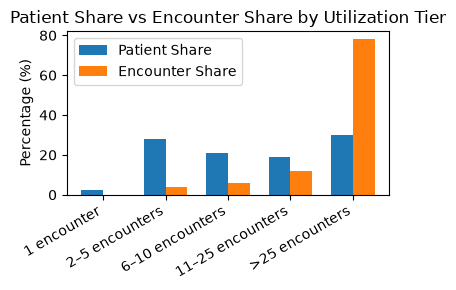

In [94]:
plt.figure(figsize=(4, 3))

x = np.arange(len(tier_encounter_summary))

width = 0.35

plt.bar(
    x - width/2,
    tier_encounter_summary["Patient Percentage"],
    width,
    label="Patient Share"
)

plt.bar(
    x + width/2,
    tier_encounter_summary["Encounter Percentage"],
    width,
    label="Encounter Share"
)

plt.xticks(
    x,
    tier_encounter_summary["Utilization Tier"],
    rotation=30,
    ha="right"
)

plt.ylabel("Percentage (%)")
plt.title("Patient Share vs Encounter Share by Utilization Tier")
plt.legend()

plt.tight_layout()
plt.show()

Patients with more than 25 encounters represent approximately 30% of patients but account for approximately 78% of all encounters.

In [96]:
patients=pd.read_csv("C:\projects\Healthcare-Analytics-Dashboard\python\data\patients.csv")

In [97]:
patient_demo = patients[
    [
        "Id",
        "BIRTHDATE",
        "GENDER",
        "RACE",
        "ETHNICITY",
        "COUNTY",
        "STATE"
    ]
].copy()

patient_demo.head()

,Id,BIRTHDATE,GENDER,RACE,ETHNICITY,COUNTY,STATE
0,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,2017-08-24,M,white,nonhispanic,Hampden County,Massachusetts
1,067318a4-db8f-447f-8b6e-f2f61e9baaa5,2016-08-01,F,white,nonhispanic,Norfolk County,Massachusetts
2,ae9efba3-ddc4-43f9-a781-f72019388548,1992-06-30,M,white,nonhispanic,Hampden County,Massachusetts
3,199c586f-af16-4091-9998-ee4cfc02ee7a,2004-01-09,F,white,nonhispanic,Plymouth County,Massachusetts
4,353016ea-a0ff-4154-85bb-1cf8b6cedf20,1996-11-15,M,white,nonhispanic,Suffolk County,Massachusetts


In [98]:
patient_demo = patient_demo.rename(
    columns={"Id": "PATIENT"}
)

patient_demo.head()

,PATIENT,BIRTHDATE,GENDER,RACE,ETHNICITY,COUNTY,STATE
0,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,2017-08-24,M,white,nonhispanic,Hampden County,Massachusetts
1,067318a4-db8f-447f-8b6e-f2f61e9baaa5,2016-08-01,F,white,nonhispanic,Norfolk County,Massachusetts
2,ae9efba3-ddc4-43f9-a781-f72019388548,1992-06-30,M,white,nonhispanic,Hampden County,Massachusetts
3,199c586f-af16-4091-9998-ee4cfc02ee7a,2004-01-09,F,white,nonhispanic,Plymouth County,Massachusetts
4,353016ea-a0ff-4154-85bb-1cf8b6cedf20,1996-11-15,M,white,nonhispanic,Suffolk County,Massachusetts


In [99]:
patient_utilization = patient_encounters.merge(
    patient_demo,
    on="PATIENT",
    how="left"
)

patient_utilization.head()

,PATIENT,encounter_count,UTILIZATION_TIER,BIRTHDATE,GENDER,RACE,ETHNICITY,COUNTY,STATE
0,0000b247-1def-417a-a783-41c8682be022,3,2–5 encounters,2007-12-03,F,white,nonhispanic,Bristol County,Massachusetts
1,00049ee8-5953-4edd-a277-b9c1b1a7f16b,8,6–10 encounters,1984-11-20,M,white,hispanic,Middlesex County,Massachusetts
2,000769a6-23a7-426e-a264-cb0e509b2da2,4,2–5 encounters,1946-11-28,F,white,nonhispanic,Bristol County,Massachusetts
3,00079a57-24a8-430f-b4f8-a1cf34f90060,20,11–25 encounters,1991-03-25,F,white,nonhispanic,Berkshire County,Massachusetts
4,0008a63c-c95c-46c2-9ef3-831d68892019,5,2–5 encounters,1993-06-16,M,white,nonhispanic,Suffolk County,Massachusetts


In [100]:
patient_utilization["PATIENT"].nunique()

12330

In [101]:
patient_utilization[[
    "PATIENT",
    "encounter_count",
    "GENDER",
    "RACE",
    "COUNTY"
]].head(10)

,PATIENT,encounter_count,GENDER,RACE,COUNTY
0,0000b247-1def-417a-a783-41c8682be022,3,F,white,Bristol County
1,00049ee8-5953-4edd-a277-b9c1b1a7f16b,8,M,white,Middlesex County
2,000769a6-23a7-426e-a264-cb0e509b2da2,4,F,white,Bristol County
3,00079a57-24a8-430f-b4f8-a1cf34f90060,20,F,white,Berkshire County
4,0008a63c-c95c-46c2-9ef3-831d68892019,5,M,white,Suffolk County
5,00093cdd-a9f0-4ad8-87e9-53534501f008,85,F,white,Suffolk County
6,000aa2a0-e307-456f-9f71-c11ab3fc024c,8,M,white,Bristol County
7,000e7adf-cbaa-4fad-ab2f-658c32f7d4d3,47,M,white,Suffolk County
8,0013bde7-14fe-482f-9547-a29077b87904,7,M,white,Worcester County
9,001683f0-8546-4ac2-9153-dd1a9ffe29cd,3,M,white,Plymouth County


In [102]:
patient_utilization["BIRTHDATE"] = pd.to_datetime(
    patient_utilization["BIRTHDATE"]
)

In [103]:
first_encounter = (
    encounters.groupby("PATIENT")["START"]
    .min()
    .reset_index(name="FIRST_ENCOUNTER")
)

first_encounter.head()

,PATIENT,FIRST_ENCOUNTER
0,0000b247-1def-417a-a783-41c8682be022,2019-01-31 14:47:48+00:00
1,00049ee8-5953-4edd-a277-b9c1b1a7f16b,1985-10-16 15:49:20+00:00
2,000769a6-23a7-426e-a264-cb0e509b2da2,1990-03-18 01:41:27+00:00
3,00079a57-24a8-430f-b4f8-a1cf34f90060,2009-05-18 12:45:02+00:00
4,0008a63c-c95c-46c2-9ef3-831d68892019,2017-10-08 21:03:20+00:00


In [104]:
patient_utilization = patient_utilization.merge(
    first_encounter,
    on="PATIENT",
    how="left"
)

In [105]:
patient_utilization["AGE_AT_FIRST_ENCOUNTER"] = (
    patient_utilization["FIRST_ENCOUNTER"].dt.year
    - patient_utilization["BIRTHDATE"].dt.year
)

In [107]:
patient_utilization["AGE_AT_FIRST_ENCOUNTER"] = (
    patient_utilization["FIRST_ENCOUNTER"]
    - patient_utilization["BIRTHDATE"]
).dt.days / 365.25

patient_utilization["AGE_AT_FIRST_ENCOUNTER"] = (
    patient_utilization["AGE_AT_FIRST_ENCOUNTER"].round(1)
)

TypeError: Cannot subtract tz-naive and tz-aware datetime-like objects

In [108]:
patient_utilization["BIRTHDATE"] = pd.to_datetime(
    patient_utilization["BIRTHDATE"]
)

patient_utilization["FIRST_ENCOUNTER"] = pd.to_datetime(
    patient_utilization["FIRST_ENCOUNTER"],
    utc=True
).dt.tz_localize(None)

In [109]:
patient_utilization[
    ["BIRTHDATE", "FIRST_ENCOUNTER"]
].dtypes

BIRTHDATE          datetime64[us]
FIRST_ENCOUNTER    datetime64[us]
dtype: object

In [110]:
patient_utilization["AGE_AT_FIRST_ENCOUNTER"] = (
    patient_utilization["FIRST_ENCOUNTER"]
    - patient_utilization["BIRTHDATE"]
).dt.days / 365.25

patient_utilization["AGE_AT_FIRST_ENCOUNTER"] = (
    patient_utilization["AGE_AT_FIRST_ENCOUNTER"].round(1)
)

In [111]:
patient_utilization[
    [
        "PATIENT",
        "BIRTHDATE",
        "FIRST_ENCOUNTER",
        "AGE_AT_FIRST_ENCOUNTER"
    ]
].head(10)

,PATIENT,BIRTHDATE,FIRST_ENCOUNTER,AGE_AT_FIRST_ENCOUNTER
0,0000b247-1def-417a-a783-41c8682be022,2007-12-03,2019-01-31 14:47:48,11.2
1,00049ee8-5953-4edd-a277-b9c1b1a7f16b,1984-11-20,1985-10-16 15:49:20,0.9
2,000769a6-23a7-426e-a264-cb0e509b2da2,1946-11-28,1990-03-18 01:41:27,43.3
3,00079a57-24a8-430f-b4f8-a1cf34f90060,1991-03-25,2009-05-18 12:45:02,18.1
4,0008a63c-c95c-46c2-9ef3-831d68892019,1993-06-16,2017-10-08 21:03:20,24.3
5,00093cdd-a9f0-4ad8-87e9-53534501f008,1952-10-19,1953-06-16 17:46:18,0.7
6,000aa2a0-e307-456f-9f71-c11ab3fc024c,1978-12-27,1981-11-20 12:57:23,2.9
7,000e7adf-cbaa-4fad-ab2f-658c32f7d4d3,1959-01-03,1977-02-26 23:33:57,18.1
8,0013bde7-14fe-482f-9547-a29077b87904,1993-03-31,2007-05-05 04:08:19,14.1
9,001683f0-8546-4ac2-9153-dd1a9ffe29cd,1992-11-14,2014-11-17 07:38:37,22.0


In [112]:
patient_utilization["AGE_AT_FIRST_ENCOUNTER"].describe()

count    12330.000000
mean        15.963366
std         12.043361
min          0.000000
25%          4.400000
50%         16.900000
75%         22.200000
max         78.400000
Name: AGE_AT_FIRST_ENCOUNTER, dtype: float64

In [113]:
patient_utilization[
    patient_utilization["AGE_AT_FIRST_ENCOUNTER"] < 0
][
    ["PATIENT", "BIRTHDATE", "FIRST_ENCOUNTER", "AGE_AT_FIRST_ENCOUNTER"]
].head()

,PATIENT,BIRTHDATE,FIRST_ENCOUNTER,AGE_AT_FIRST_ENCOUNTER


In [114]:
bins = [0, 18, 35, 50, 65, 80]

labels = [
    "<18",
    "18-34",
    "35-49",
    "50-64",
    "65-79"
]

patient_utilization["AGE_GROUP"] = pd.cut(
    patient_utilization["AGE_AT_FIRST_ENCOUNTER"],
    bins=bins,
    labels=labels,
    right=False
)

In [115]:
patient_utilization["AGE_GROUP"].value_counts().sort_index()

AGE_GROUP
<18      6465
18-34    4904
35-49     895
50-64      54
65-79      12
Name: count, dtype: int64

So do not interpret this as evidence that children inherently have higher healthcare utilization. The dataset itself is heavily concentrated in younger patients, which we need to account for when comparing utilization.

Encounter burden by age group

In [117]:
age_utilization_summary = (
    patient_utilization
    .groupby("AGE_GROUP", observed=True)["encounter_count"]
    .agg(["count", "sum", "median", "mean"])
    .reset_index()
)

age_utilization_summary.columns = [
    "Age Group",
    "Patient Count",
    "Encounter Count",
    "Median Encounters",
    "Mean Encounters"
]

age_utilization_summary

,Age Group,Patient Count,Encounter Count,Median Encounters,Mean Encounters
0,<18,6465,148183,9.0,22.920804
1,18-34,4904,157065,14.0,32.027936
2,35-49,895,15594,7.0,17.423464
3,50-64,54,595,6.0,11.018519
4,65-79,12,91,3.0,7.583333


In [119]:
age_utilization_summary["Patient Percentage"] = (
    age_utilization_summary["Patient Count"]
    / age_utilization_summary["Patient Count"].sum()
    * 100
)

age_utilization_summary["Encounter Percentage"] = (
    age_utilization_summary["Encounter Count"]
    / age_utilization_summary["Encounter Count"].sum()
    * 100
)

age_utilization_summary

,Age Group,Patient Count,Encounter Count,Median Encounters,Mean Encounters,Patient Percentage,Encounter Percentage
0,<18,6465,148183,9.0,22.920804,52.433090,46.087121
1,18-34,4904,157065,14.0,32.027936,39.772912,48.849556
2,35-49,895,15594,7.0,17.423464,7.258719,4.849966
3,50-64,54,595,6.0,11.018519,0.437956,0.185054
4,65-79,12,91,3.0,7.583333,0.097324,0.028302


Which encounter types are most common across different age groups?

Bring AGE_GROUP into encounters

In [120]:
encounters_age = encounters.merge(
    patient_utilization[["PATIENT", "AGE_GROUP"]],
    on="PATIENT",
    how="left"
)

encounters_age.head()

,Id,START,STOP,PATIENT,ORGANIZATION,PROVIDER,PAYER,ENCOUNTERCLASS,CODE,DESCRIPTION,BASE_ENCOUNTER_COST,TOTAL_CLAIM_COST,PAYER_COVERAGE,REASONCODE,REASONDESCRIPTION,DURATION_HOURS,YEAR,UTILIZATION_GROUP,AGE_GROUP
0,d5ee30a9-362f-429e-a87a-ee38d999b0a5,2019-02-16 01:02:32+00:00,2019-02-16 01:17:32+00:00,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,5103c940-0c08-392f-95cd-446e0cea042a,e2c226c2-3e1e-3d0b-b997-ce9544c10528,7c4411ce-02f1-39b5-b9ec-dfbea9ad3c1a,outpatient,185345009,Encounter for symptom,129.16,129.16,69.16,65363002.0,Otitis media,0.250000,2019,Other Patients,<18
1,6a74fdef-2287-44bf-b9e7-18012376faca,2019-08-02 01:02:32+00:00,2019-08-02 01:32:32+00:00,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,0b9f3f7c-8ab6-30a5-b3ae-4dc0e0c00cb3,87c33fc5-3fd1-3c52-815a-b89a1623bb3a,7c4411ce-02f1-39b5-b9ec-dfbea9ad3c1a,wellness,410620009,Well child visit (procedure),129.16,129.16,129.16,NaN,NaN,0.500000,2019,Other Patients,<18
2,8bca6d8a-ab80-4cbf-8abb-46654235f227,2019-10-31 01:02:32+00:00,2019-10-31 01:17:32+00:00,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,5103c940-0c08-392f-95cd-446e0cea042a,e2c226c2-3e1e-3d0b-b997-ce9544c10528,7c4411ce-02f1-39b5-b9ec-dfbea9ad3c1a,outpatient,185345009,Encounter for symptom,129.16,129.16,69.16,65363002.0,Otitis media,0.250000,2019,Other Patients,<18
3,821e57ac-9304-46a9-9f9b-83daf60e9e43,2020-01-31 01:02:32+00:00,2020-01-31 01:17:32+00:00,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,0b9f3f7c-8ab6-30a5-b3ae-4dc0e0c00cb3,87c33fc5-3fd1-3c52-815a-b89a1623bb3a,7c4411ce-02f1-39b5-b9ec-dfbea9ad3c1a,wellness,410620009,Well child visit (procedure),129.16,129.16,129.16,NaN,NaN,0.250000,2020,Other Patients,<18
4,681c380b-3c84-4c55-80a6-db3d9ea12fee,2020-03-02 01:02:32+00:00,2020-03-02 01:58:32+00:00,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,fd328395-ab1d-35c6-a2d0-d05a9a79cf11,9c875a09-93e0-39aa-9260-ad264bbdd3fe,7c4411ce-02f1-39b5-b9ec-dfbea9ad3c1a,ambulatory,185345009,Encounter for symptom (procedure),129.16,129.16,69.16,NaN,NaN,0.933333,2020,Other Patients,<18


In [122]:
patient_utilization.head()

,PATIENT,encounter_count,UTILIZATION_TIER,BIRTHDATE,GENDER,RACE,ETHNICITY,COUNTY,STATE,FIRST_ENCOUNTER,AGE_AT_FIRST_ENCOUNTER,AGE_GROUP
0,0000b247-1def-417a-a783-41c8682be022,3,2–5 encounters,2007-12-03,F,white,nonhispanic,Bristol County,Massachusetts,2019-01-31 14:47:48,11.2,<18
1,00049ee8-5953-4edd-a277-b9c1b1a7f16b,8,6–10 encounters,1984-11-20,M,white,hispanic,Middlesex County,Massachusetts,1985-10-16 15:49:20,0.9,<18
2,000769a6-23a7-426e-a264-cb0e509b2da2,4,2–5 encounters,1946-11-28,F,white,nonhispanic,Bristol County,Massachusetts,1990-03-18 01:41:27,43.3,35-49
3,00079a57-24a8-430f-b4f8-a1cf34f90060,20,11–25 encounters,1991-03-25,F,white,nonhispanic,Berkshire County,Massachusetts,2009-05-18 12:45:02,18.1,18-34
4,0008a63c-c95c-46c2-9ef3-831d68892019,5,2–5 encounters,1993-06-16,M,white,nonhispanic,Suffolk County,Massachusetts,2017-10-08 21:03:20,24.3,18-34


In [123]:
encounters_age["AGE_GROUP"].isna().sum()

np.int64(0)

In [124]:
encounters_age["AGE_GROUP"].value_counts(dropna=False)

AGE_GROUP
18-34    157065
<18      148183
35-49     15594
50-64       595
65-79        91
Name: count, dtype: int64

In [125]:
age_encounter_summary = (
    encounters_age
    .groupby(["AGE_GROUP", "ENCOUNTERCLASS"], observed=True)
    .size()
    .reset_index(name="Encounter Count")
)

age_encounter_summary

,AGE_GROUP,ENCOUNTERCLASS,Encounter Count
0,<18,ambulatory,40619
1,<18,emergency,3949
2,<18,inpatient,4582
3,<18,outpatient,25550
4,<18,urgentcare,1735
5,<18,wellness,71748
6,18-34,ambulatory,37821
7,18-34,emergency,2786
8,18-34,inpatient,4186
9,18-34,outpatient,30711


Calculate within-age-group percentages

In [ ]:
age_encounter_summary["Percentage"] = (
    age_encounter_summary["Encounter Count"]
    / age_encounter_summary.groupby("AGE_GROUP")["Encounter Count"].transform("sum")  #transorm(sum) adds all encounter count of each age group into one 
    * 100
)

age_encounter_summary["Percentage"] = (
    age_encounter_summary["Percentage"].round(2)
)

age_encounter_summary

,AGE_GROUP,ENCOUNTERCLASS,Encounter Count,Percentage
0,<18,ambulatory,40619,27.41
1,<18,emergency,3949,2.66
2,<18,inpatient,4582,3.09
3,<18,outpatient,25550,17.24
4,<18,urgentcare,1735,1.17
5,<18,wellness,71748,48.42
6,18-34,ambulatory,37821,24.08
7,18-34,emergency,2786,1.77
8,18-34,inpatient,4186,2.67
9,18-34,outpatient,30711,19.55


Find the dominant encounter type in each age group

In [128]:
dominant_encounter_by_age = (
    age_encounter_summary
    .loc[
        age_encounter_summary.groupby("AGE_GROUP")["Percentage"].idxmax()         #idxmax() means: "Which category has the highest value within each group?"

                                                                                  #Return the index/row label where the maximum value occurs.
    ]
    .sort_values("AGE_GROUP")
)

dominant_encounter_by_age

,AGE_GROUP,ENCOUNTERCLASS,Encounter Count,Percentage
5,<18,wellness,71748,48.42
11,18-34,wellness,79448,50.58
12,35-49,ambulatory,7329,47.00
18,50-64,ambulatory,276,46.39
29,65-79,wellness,50,54.95


Create the heatmap

In [129]:
import pandas as pd
import matplotlib.pyplot as plt

heatmap_data = age_encounter_summary.pivot(
    index="AGE_GROUP",
    columns="ENCOUNTERCLASS",
    values="Percentage"
)

heatmap_data = heatmap_data.reindex(
    ["<18", "18-34", "35-49", "50-64", "65-79"]
)

heatmap_data

ENCOUNTERCLASS,ambulatory,emergency,inpatient,outpatient,urgentcare,wellness
AGE_GROUP,,,,,,
<18,27.41,2.66,3.09,17.24,1.17,48.42
18-34,24.08,1.77,2.67,19.55,1.35,50.58
35-49,47.00,2.98,4.82,13.38,1.28,30.54
50-64,46.39,4.20,10.42,2.86,0.84,35.29
65-79,26.37,9.89,3.30,2.20,3.30,54.95


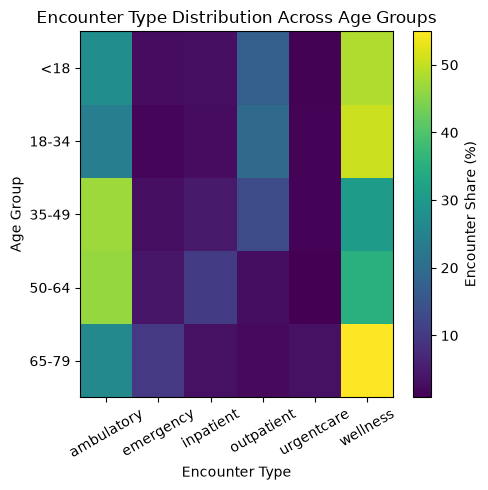

In [131]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 5))

plt.imshow(heatmap_data, aspect="auto")

plt.xticks(
    range(len(heatmap_data.columns)),
    heatmap_data.columns,
    rotation=30
)

plt.yticks(
    range(len(heatmap_data.index)),
    heatmap_data.index
)

plt.colorbar(label="Encounter Share (%)")

plt.title("Encounter Type Distribution Across Age Groups")
plt.xlabel("Encounter Type")
plt.ylabel("Age Group")

plt.tight_layout()
plt.show()

# Repeat-Encounter / Return-Utilization Analysis

How common are repeat encounters, and how much of the healthcare utilization comes from patients returning for multiple encounters?

In [132]:
patient_encounters["RETURN_STATUS"] = patient_encounters["encounter_count"].apply(
    lambda x: "Repeat Encounter" if x >= 2 else "Single Encounter"
)

patient_encounters["RETURN_STATUS"].value_counts()

RETURN_STATUS
Repeat Encounter    12054
Single Encounter      276
Name: count, dtype: int64

In [133]:
repeat_encounter_summary = (
    patient_encounters
    .groupby("RETURN_STATUS", observed=True)["encounter_count"]
    .agg(["count", "sum", "median", "mean"])
    .reset_index()
)

repeat_encounter_summary.columns = [
    "Return Status",
    "Patient Count",
    "Encounter Count",
    "Median Encounters",
    "Mean Encounters"
]

repeat_encounter_summary

,Return Status,Patient Count,Encounter Count,Median Encounters,Mean Encounters
0,Repeat Encounter,12054,321252,10.0,26.65107
1,Single Encounter,276,276,1.0,1.00000


Do repeat patients represent a relatively small proportion of patients but generate a disproportionately large proportion of encounters?

In [134]:
repeat_encounter_summary["Patient Percentage"] = (
    repeat_encounter_summary["Patient Count"]
    / repeat_encounter_summary["Patient Count"].sum()
    * 100
)

repeat_encounter_summary["Encounter Percentage"] = (
    repeat_encounter_summary["Encounter Count"]
    / repeat_encounter_summary["Encounter Count"].sum()
    * 100
)

repeat_encounter_summary

,Return Status,Patient Count,Encounter Count,Median Encounters,Mean Encounters,Patient Percentage,Encounter Percentage
0,Repeat Encounter,12054,321252,10.0,26.65107,97.761557,99.91416
1,Single Encounter,276,276,1.0,1.00000,2.238443,0.08584


12,054 / 12,330 patients had at least 2 encounters.
Only 276 patients had exactly 1 encounter.
Repeat-encounter patients generated essentially all encounters (99.91%).
Among repeat patients, the average was 26.65 encounters per patient.

Repeat Utilization by Age Group(Which age groups have the highest proportion of patients with repeat encounters?)

In [136]:
patient_encounters

,PATIENT,encounter_count,UTILIZATION_TIER,RETURN_STATUS
0,0000b247-1def-417a-a783-41c8682be022,3,2–5 encounters,Repeat Encounter
1,00049ee8-5953-4edd-a277-b9c1b1a7f16b,8,6–10 encounters,Repeat Encounter
2,000769a6-23a7-426e-a264-cb0e509b2da2,4,2–5 encounters,Repeat Encounter
3,00079a57-24a8-430f-b4f8-a1cf34f90060,20,11–25 encounters,Repeat Encounter
4,0008a63c-c95c-46c2-9ef3-831d68892019,5,2–5 encounters,Repeat Encounter
...,...,...,...,...
12325,ffd3d544-1fcd-4a87-9514-fa6c37409cbc,75,>25 encounters,Repeat Encounter
12326,ffd86fda-ebb9-400e-9fe3-ea1a1037dbad,14,11–25 encounters,Repeat Encounter
12327,ffdbbb1b-745e-4e38-ade2-a19d6e778fee,34,>25 encounters,Repeat Encounter
12328,ffdf0900-bc4b-4f81-b95b-1ea57da21e07,36,>25 encounters,Repeat Encounter


Add AGE_GROUP to patient_encounters

In [138]:
patient_encounters = patient_encounters.merge(
    patient_utilization[["PATIENT", "AGE_GROUP"]],
    on="PATIENT",
    how="left"
)

In [139]:
patient_encounters[["PATIENT", "encounter_count", "RETURN_STATUS", "AGE_GROUP"]].head()

,PATIENT,encounter_count,RETURN_STATUS,AGE_GROUP
0,0000b247-1def-417a-a783-41c8682be022,3,Repeat Encounter,<18
1,00049ee8-5953-4edd-a277-b9c1b1a7f16b,8,Repeat Encounter,<18
2,000769a6-23a7-426e-a264-cb0e509b2da2,4,Repeat Encounter,35-49
3,00079a57-24a8-430f-b4f8-a1cf34f90060,20,Repeat Encounter,18-34
4,0008a63c-c95c-46c2-9ef3-831d68892019,5,Repeat Encounter,18-34


In [140]:
patient_encounters["AGE_GROUP"].isna().sum()

np.int64(0)

In [141]:
repeat_by_age = (
    patient_encounters
    .groupby(["AGE_GROUP", "RETURN_STATUS"], observed=True)
    .size()
    .reset_index(name="Patient Count")
)

repeat_by_age

,AGE_GROUP,RETURN_STATUS,Patient Count
0,<18,Repeat Encounter,6381
1,<18,Single Encounter,84
2,18-34,Repeat Encounter,4740
3,18-34,Single Encounter,164
4,35-49,Repeat Encounter,868
5,35-49,Single Encounter,27
6,50-64,Repeat Encounter,53
7,50-64,Single Encounter,1
8,65-79,Repeat Encounter,12


In [142]:
repeat_by_age["Percentage"] = (
    repeat_by_age["Patient Count"]
    / repeat_by_age.groupby("AGE_GROUP")["Patient Count"].transform("sum")
    * 100
).round(2)

repeat_by_age

,AGE_GROUP,RETURN_STATUS,Patient Count,Percentage
0,<18,Repeat Encounter,6381,98.70
1,<18,Single Encounter,84,1.30
2,18-34,Repeat Encounter,4740,96.66
3,18-34,Single Encounter,164,3.34
4,35-49,Repeat Encounter,868,96.98
5,35-49,Single Encounter,27,3.02
6,50-64,Repeat Encounter,53,98.15
7,50-64,Single Encounter,1,1.85
8,65-79,Repeat Encounter,12,100.00


The difference between age groups is relatively small; repeat utilization is a dataset-wide pattern rather than something confined to one age group.

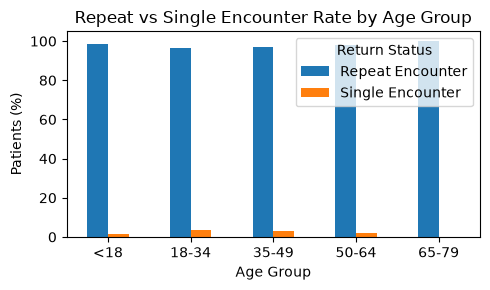

In [144]:
import matplotlib.pyplot as plt

plot_data = repeat_by_age.pivot(
    index="AGE_GROUP",
    columns="RETURN_STATUS",
    values="Percentage"
)

plot_data = plot_data.reindex(
    ["<18", "18-34", "35-49", "50-64", "65-79"]
)

plot_data.plot(
    kind="bar",
    figsize=(5, 3)
)

plt.title("Repeat vs Single Encounter Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Patients (%)")
plt.xticks(rotation=0)
plt.legend(title="Return Status")
plt.tight_layout()
plt.show()

the 65–79 group has only 12 patients, so the 100% repeat rate should not be interpreted as strong evidence of higher utilization in older patients. The small sample size makes that estimate unstable.